# Differential edges

improve as previous attempt by using better count matrices for RNA & ATAC. something wrong with Ricards?
pseudobulk replicates using own code but with lognormalisation.

2 ideas:

Method 1: logFC on RNA & ATAC using limma -> transform back to FC -> edge FC = RNA FC * ATAC FC (RNAL ATAC can compensate each other) -> Edge LogFC. ignore target gene for calculation but keep for display.
        

Method 2: calculate edge value by RNA *ATAC -> calculate diff edges using Limma

In [1]:
here::i_am("rna_atac/diff_edge_SCENIC.ipynb")
suppressPackageStartupMessages(library(igraph))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(GGally))
suppressPackageStartupMessages(library(igraph))
suppressPackageStartupMessages(library(network))
suppressPackageStartupMessages(library(sna))
# suppressMessages(library(intergraph))
suppressPackageStartupMessages(library(ggraph))
suppressPackageStartupMessages(library(tibble))
suppressPackageStartupMessages(library(tidygraph))
suppressPackageStartupMessages(library(parallel))
# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(42)

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘destiny’ was built under R version 4.1.3”
Warning message:
“package ‘network’ was built under R version 4.1.3”
Warning message:
“package ‘sna’ was built under R version 4.1.3”
Warning message:
“package ‘statnet.common’ was built under R version 4.1.3”
Warning message:
“package ‘tidygraph’ was built under R version 4.1.3”


In [2]:
#####################
## Define settings ##
#####################

# args$rna_cells.sce <- io$rna.sce
args = list()
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$rna.counts = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')
args$atac.counts = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds')

args$outdir <- file.path(io$basedir,"results/rna_atac/gene_regulatory_networks/differential")

io$trajectory = "epiblast_blood"

dir.create(args$outdir, showWarnings=F, recursive=T)

all_TFs = stringr::str_to_title(fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/TFs.txt", header=F)$V1)

if (io$trajectory=="epiblast_blood") {
  celltypes.to.plot <- c("Epiblast",
                        "Primitive_Streak" ,
                        "Nascent_mesoderm",
                        "Mixed_mesoderm",
                        "ExE_mesoderm",
                        "Allantois",
                        "Mesenchyme",
                        "Haematoendothelial_progenitors",
                        "Endothelium",
                        "Blood_progenitors_1",
                        "Blood_progenitors_2",
                        "Erythroid1",
                        "Erythroid2",
                        "Erythroid3")
}

theme_graph <- function() {
  theme_classic() +
    theme(
      axis.line = element_blank(), 
      axis.text = element_blank(),
      axis.ticks = element_blank(), 
      axis.title = element_blank(),
      legend.position = "none"
    )
}

In [3]:
sample_metadata = fread(args$metadata)[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE]

#### SCENIC network

In [238]:
# load SCENIC+ eGRN
eGRN = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/scenicplus/blood/scenicplus/eRegulon_metadata_filtered.csv')

In [239]:
# Subset to in silico ChIP
silico_chip = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/metacells/trajectories/from_scratch/TF2gene_after_virtual_chip.txt.gz') %>%
    .[,c('tf', 'peak')] %>% setnames(c('TF', 'Region')) %>% # keep only TF - peak predicted binding
    .[,TF:=str_to_title(TF)] %>%
    unique(by=c('TF', 'Region'))

In [240]:
#eGRN = merge(eGRN, silico_chip, by=c('TF', 'Region'))

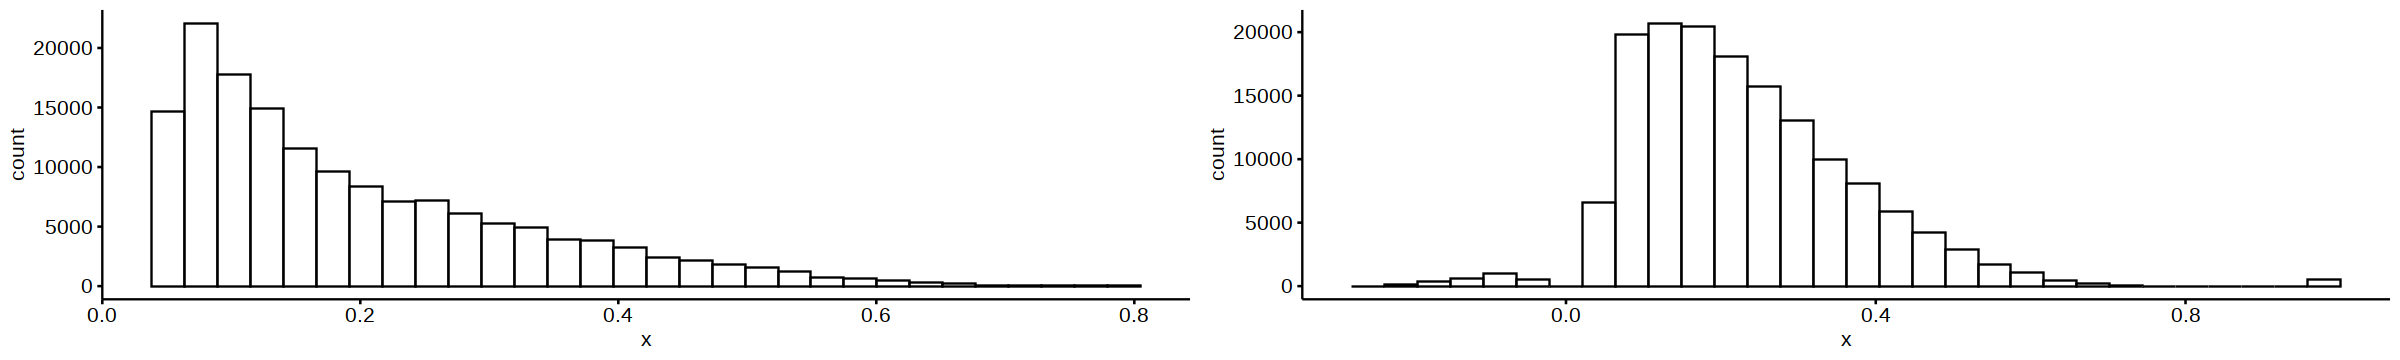

In [241]:
options(repr.plot.width=20, repr.plot.height=3)
ggarrange(gghistogram(eGRN$R2G_rho, bins=30), gghistogram(eGRN$TF2G_rho, bins=30))

In [244]:
eGRN_filt = eGRN %>% # filter to TFs that correlate with Gene
    .[abs(TF2G_rho) > 0.2 & abs(R2G_rho) > 0.3 ] %>%
    .[,sign:=ifelse(TF2G_rho <=0, 'Negative', 'Positive')]

In [245]:
nrow(eGRN)
nrow(eGRN_filt)

[1] 152173

[1] 23384

In [246]:
summary(duplicated(eGRN_filt[,c('TF', 'Region', 'Gene')]))

   Mode   FALSE 
logical   23384 

#### Artificial replicates

In [247]:
sample_metadata$group = sample_metadata$celltype_genotype

replicates = mclapply(unique(sample_metadata$group), function(i){
    cell_list = list()
    tmp = sample_metadata[group==i]
    if(nrow(tmp) >= 25){
        message(i)
        for(x in 1:5){
            # sample 80% of cells per pseudoreplicate
            sample = tmp[sample(1:nrow(tmp), size=nrow(tmp)*0.8,  replace = TRUE)]
            cell_list[[x]] = data.table(group = i, replicate = x, cell = sample$cell)
        }
        cells = do.call('rbind', cell_list)
    }
}, mc.cores=16) %>% rbindlist()
#names(replicates) = unique(sample_metadata$group)

In [248]:
head(replicates)

group,replicate,cell
<chr>,<int>,<chr>
Epiblast-wt,1,1A_Eo_DEG_G9_day3#TGTGCAAGTGAGGTGA-1
Epiblast-wt,1,1A_Eo_DEG_G9_day3#TCCATAAAGTCAATCA-1
Epiblast-wt,1,1B_Eo_DEG_G9_day3#TAGCGGACACAACAGG-1
Epiblast-wt,1,1B_Eo_DEG_G9_day3#ATTAGTCCACCAGCAT-1
Epiblast-wt,1,1A_Eo_DEG_G9_day3#AACGGTAAGCGTGCAC-1
Epiblast-wt,1,1A_Eo_DEG_G9_day3#CTTGCATGTTGTTGCT-1


#### RNA Pseudobulking with artificial replicates

In [249]:
sce = readRDS(args$rna.counts)[, sample_metadata$cell]

In [250]:
sce = sce[unique(c(eGRN_filt$TF, eGRN_filt$Gene)),]

In [251]:
sce

class: SingleCellExperiment 
dim: 1547 33177 
metadata(0):
assays(1): counts
rownames(1547): Arid3a Arid3b ... Fam114a1 Hs3st5
rowData names(0):
colnames(33177): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(11): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [252]:
# replicates will be made per pool, celltype, and tdTom_corr status
#sample_metadata$group = paste0(sample_metadata$celltype.mapped_mnn, '_', sample_metadata$tdTom_corr)
sample_metadata$group = sample_metadata$celltype_genotype
sce$group = sample_metadata$group 

pseudobulk_replicate = mclapply(unique(replicates$group), function(i){
    summed_list = list()
    tmp = replicates[group==i]
    if(nrow(tmp) >= 25){
        message(i)
        for(x in 1:5){
            # sample 80% of cells per pseudoreplicate
            cells = tmp[replicate == x, cell]
            sce_tmp = sce[,cells]
            sce_tmp$ncells = length(cells)

            summed_list[[x]] <- aggregateAcrossCells(sce_tmp, id=sce_tmp$group, BPPARAM = BPPARAM)
            colnames(summed_list[[x]]) = paste0(colnames(summed_list[[x]]), '_rep', x)
            }
        pseudobulk_group = do.call('cbind', summed_list)
        return(pseudobulk_group)
    }
}, mc.cores=16) 
pseudobulk_replicate = do.call('cbind', compact(pseudobulk_replicate))

In [253]:
# log normalisation 
logcounts(pseudobulk_replicate) <- log2(1e6*(sweep(counts(pseudobulk_replicate),2,colSums(counts(pseudobulk_replicate)),"/"))+1)

In [254]:
pseudobulk_replicate_rna = pseudobulk_replicate

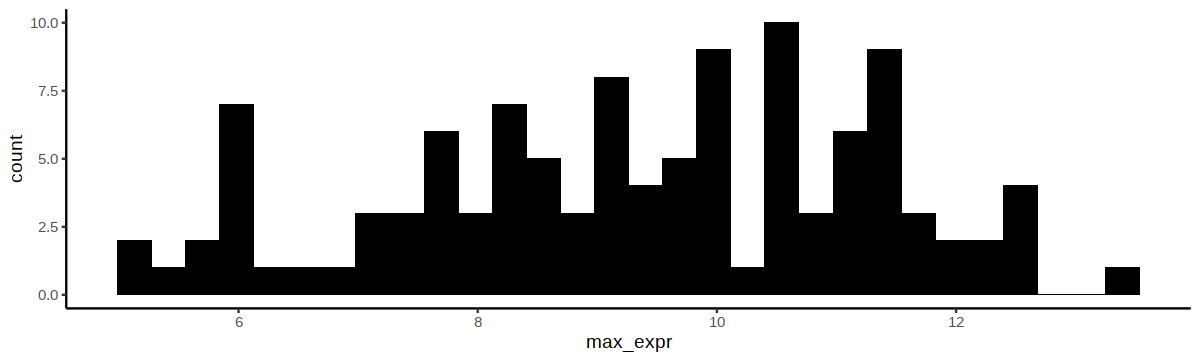

In [255]:
# filter selected TFs 
all_TFs = all_TFs[all_TFs %in% rownames(pseudobulk_replicate)]
max_expr = data.table(TF = all_TFs, max_expr = rowMax(logcounts(pseudobulk_replicate[all_TFs,])))
options(repr.plot.width=10, repr.plot.height=3)
ggplot(max_expr, aes(max_expr)) + geom_histogram(fill='black',bins = 30) + theme_classic()

# Keep only TFs that have a minimum of expression of 4 in one replicate
TF_keep = max_expr[max_expr>4, TF]

In [256]:
pseudobulk_replicate_rna$celltype = str_split(pseudobulk_replicate_rna$group, '-') %>% map_chr(1)

#### ATAC Pseudobulking with artificial replicates

In [257]:
sce = readRDS(args$atac.counts)[, sample_metadata$cell]

In [258]:
sce = sce[unique(eGRN_filt$Region),]

In [259]:
sce@assays@data$counts = sce@assays@data$PeakMatrix_atlas

In [260]:
# replicates will be made per pool, celltype, and tdTom_corr status
#sample_metadata$group = paste0(sample_metadata$celltype.mapped_mnn, '_', sample_metadata$tdTom_corr)
sample_metadata$group = sample_metadata$celltype_genotype
sce$group = sample_metadata$group 

pseudobulk_replicate = mclapply(unique(replicates$group), function(i){
    summed_list = list()
    tmp = replicates[group==i]
    if(nrow(tmp) >= 25){
        message(i)
        for(x in 1:5){
            # sample 80% of cells per pseudoreplicate
            cells = tmp[replicate == x, cell]
            sce_tmp = sce[,cells]
            sce_tmp$ncells = length(cells)

            summed_list[[x]] <- aggregateAcrossCells(sce_tmp, id=sce_tmp$group, BPPARAM = BPPARAM)
            colnames(summed_list[[x]]) = paste0(colnames(summed_list[[x]]), '_rep', x)
            }
        pseudobulk_group = do.call('cbind', summed_list)
        return(pseudobulk_group)
    }
}, mc.cores=16) 
pseudobulk_replicate = do.call('cbind', compact(pseudobulk_replicate))

In [261]:
pseudobulk_replicate = as(pseudobulk_replicate, 'SingleCellExperiment')

In [262]:
# log normalisation 
logcounts(pseudobulk_replicate) <- log2(1e6*(sweep(counts(pseudobulk_replicate),2,colSums(counts(pseudobulk_replicate)),"/"))+1)

In [263]:
pseudobulk_replicate_atac = pseudobulk_replicate

In [264]:
pseudobulk_replicate_atac$celltype = str_split(pseudobulk_replicate_atac$group, '-') %>% map_chr(1)

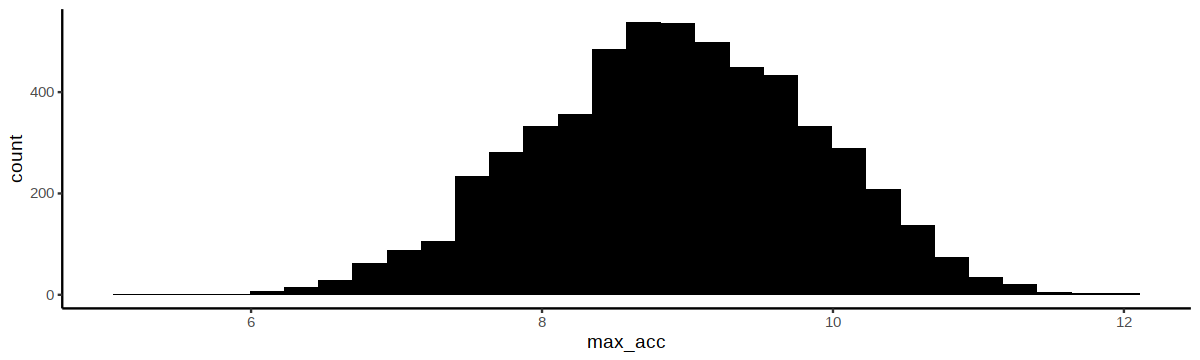

In [265]:
max_acc = data.table(region = rownames(pseudobulk_replicate_atac), max_acc = rowMax(logcounts(pseudobulk_replicate_atac)))
options(repr.plot.width=10, repr.plot.height=3)
ggplot(max_acc, aes(max_acc)) + geom_histogram(fill='black',bins = 30) + theme_classic()

# Keep only regions that have a minimum of expression 
# Nice normal distribution so I'm only going to exclude very bottom part
regions_keep = max_acc[max_acc>1, region]

#### Filter eGRN based on maximum expression & accessibility

In [266]:
eGRN_filt = eGRN_filt[TF %in% TF_keep & Region %in% regions_keep] %>%
    .[,idx:=.I]

In [267]:
# subset ATAC 
pseudobulk_replicate_atac = pseudobulk_replicate_atac[unique(eGRN_filt$Region),]

In [268]:
# subset RNA
pseudobulk_replicate_rna = pseudobulk_replicate_rna[unique(c(eGRN_filt$TF, eGRN_filt$Gene))]

# No minmax normalisation

### method 1

In [269]:
# DEGs on RNA
DEGs <- pseudoBulkDGE(pseudobulk_replicate_rna,
    label=pseudobulk_replicate_rna$celltype,
    design=~genotype,
    coef="genotypewt",
    method='edgeR') %>% unlist() %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [270]:
# DARs on ATAC
DARs <- pseudoBulkDGE(pseudobulk_replicate_atac,
    label=pseudobulk_replicate_atac$celltype,
    design=~genotype,
    coef="genotypewt",
    method='edgeR') %>% unlist() %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(Region=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [271]:
plot_network = function(celltype_i, logFC_RNA, logFC_ATAC, logFC_edge){
    tmp = eGRN_filt[,c('TF', 'Region', 'Gene')] %>%
        merge(., DEGs[celltype==celltype_i, c('gene', 'logFC', 'FDR')], by.x='TF', by.y='gene') %>%
        setnames(c('logFC', 'FDR'), c('logFC_RNA', 'FDR_RNA')) %>%
        merge(., DARs[celltype==celltype_i, c('Region', 'logFC', 'FDR')], by='Region') %>%
        setnames(c('logFC', 'FDR'), c('logFC_ATAC', 'FDR_ATAC')) %>% 
        .[,`:=`(FC_RNA = 2^logFC_RNA, FC_ATAC = 2^logFC_ATAC)] %>%
        .[,edge_FC := FC_RNA * FC_ATAC] %>%
        .[,edge_logFC := log2(edge_FC)]

    edges = tmp[abs(edge_logFC) > logFC_edge] %>%
            .[, c('TF', 'Region', 'Gene', 'edge_logFC')] %>%
            .[order(-abs(edge_logFC))] %>%
            unique(by=c('TF', 'Gene')) %>% 
            .[, N:=.N, by=TF] %>% .[N>3] %>%
            .[,edge_logFC:= ifelse(edge_logFC <= -quantile(abs(edge_logFC), .95), -quantile(abs(edge_logFC), .95), 
                                   ifelse(edge_logFC>=quantile(abs(edge_logFC), .95), quantile(abs(edge_logFC), .95), edge_logFC))]# quantile cutoff logFC

    nodes = data.table(gene = unique(c(edges$TF, edges$Gene))) %>%
            .[,type:=ifelse(gene %in% all_TFs, 'TF', 'TG')] %>%
            .[,size:=ifelse(type=='TF', 4, 1.5)] %>%
            merge(.,DEGs[celltype==celltype_i,c('gene', 'logFC', 'FDR')], by='gene', all.x=TRUE) %>%
           .[gene %in% unique(c(edges$TF, edges$Gene)),] %>%
           .[,logFC:=ifelse(FDR>0.05, 0, logFC)] %>%
           .[,logFC:=ifelse(is.na(logFC), 0, logFC)] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC
    
    igraph.tbl_tmp = tbl_graph(edges = edges[, c('TF', 'Gene', 'edge_logFC')], nodes = nodes)

    options(repr.plot.width=20, repr.plot.height=8)
    p = ggraph(igraph.tbl_tmp, 'fr') + #'fr'
        # Edges
            geom_edge_fan(aes( edge_color=edge_logFC), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(2,'mm'), show.legend = T) + #filter=score>score_thr, 
            scale_edge_alpha_continuous(range=c(0,1), name='abs(edge logFC)') +
            scale_edge_colour_gradient2(low='red', mid='grey90', high='darkgreen', name='Edge LogFC') +
            # Nodes
            geom_node_point(aes(fill=logFC, size=size), shape=21) + #It looks nice to filter above a threshold but it's not fair because TF-peak are higher than peak-target, and there is no minmax norm so far
            geom_node_text(aes(filter=type=='TF', label=gene)) + # , size=3.75| type=='target'
            scale_fill_gradient2(low='blue', mid='white', high='orange', name='Gene LogFC') +
            scale_size_continuous(range(1,2), guide='none') + 
            # theme
            theme_graph() + theme(
                    legend.position = "right",
                    text=element_text(size=20)) + 
            ggtitle(paste(celltype_i, 'KO vs WT'))
    return(p)
}

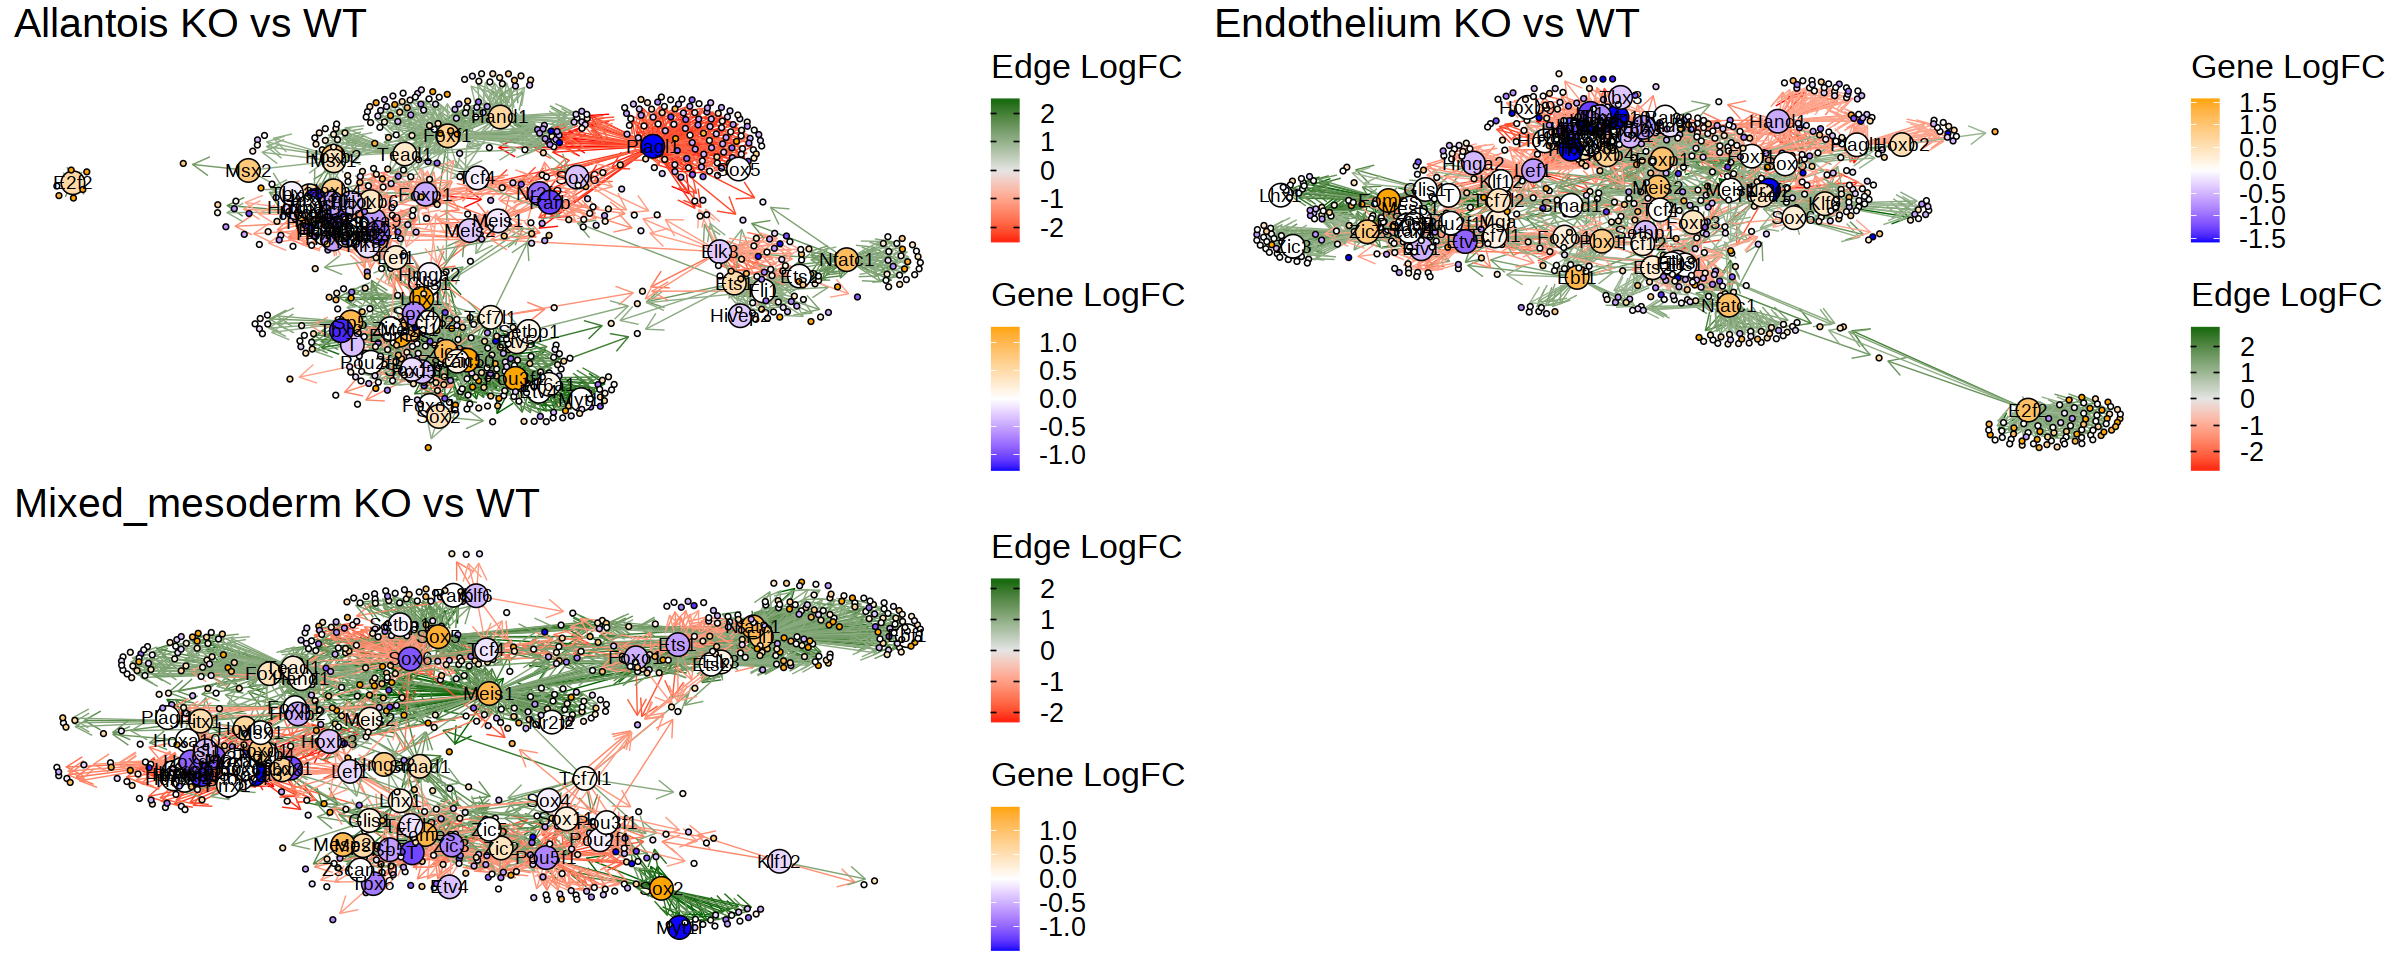

In [272]:
options(repr.plot.width=20, repr.plot.height=15)
ggarrange(
    plot_network('Allantois', 1, 1, 1),
    plot_network('Endothelium', 1, 1, 1),
    plot_network('Mixed_mesoderm', 1, 1, 1)
)

### Method 2
doesn't really seem to work well eventhough most similar to previous approach

In [273]:
# Create SCE where rows are GRN edges and columns are replicates
# for every replicate, multiply TF * acc -> make dataframe with values
# then cbind all
edge_values.dt = mclapply(unique(colnames(pseudobulk_replicate_atac)), function(x){
           tmp = data.table(idx = eGRN_filt$idx,
                            group_replicate = x,
                            logcounts(pseudobulk_replicate_rna[eGRN_filt$TF,x]),
                            logcounts(pseudobulk_replicate_atac[eGRN_filt$Region,x])) %>% 
                 setnames(c('idx', 'group_replicate', 'RNA', 'ATAC')) %>%
                 .[,edge_value := round(RNA * ATAC, 2)] %>%
                 .[,c('idx', 'group_replicate', 'edge_value')]
            return(tmp)
}, mc.cores=16) %>% rbindlist()


In [274]:
# Convert to matrix
edge_values.mtx = dcast(edge_values.dt, idx ~ group_replicate, value.var = "edge_value") %>% 
    as.data.frame() %>%
    tibble::column_to_rownames('idx') %>%
    as.matrix()

# Convert to SCE
edge_values.sce = SingleCellExperiment(list(counts = edge_values.mtx))
colData(edge_values.sce) = colData(pseudobulk_replicate_rna)

In [275]:
# Differential test with limma using pseudoBulkDGE

between.res <- pseudoBulkDGE(edge_values.sce,
    label=edge_values.sce$celltype,
    design=~genotype,
    coef="genotypewt",
    method='voom') %>% unlist() %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & adj.P.Val<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),] %>%
            setnames('gene', 'idx')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [276]:
plot_network = function(celltype_i, logFC_i){
    edges = between.res[celltype==celltype_i & sig==TRUE & abs(logFC) > logFC_i] %>%
                .[, idx:=as.integer(idx)] %>%
                merge(., eGRN_filt, by= 'idx') %>%
                .[, c('TF', 'Region', 'Gene', 'logFC')] %>%
                .[, N:=.N, by=TF] %>% .[N>3] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC

    nodes = data.table(gene = unique(c(edges$TF, edges$Gene))) %>%
            .[,type:=ifelse(gene %in% all_TFs, 'TF', 'TG')] %>%
            .[,size:=ifelse(type=='TF', 4, 1.5)] %>%
            merge(.,DEGs[celltype==celltype_i,c('gene', 'logFC', 'FDR')], by='gene', all.x=TRUE) %>%
           .[gene %in% unique(c(edges$TF, edges$Gene)),] %>%
            unique(by='gene') %>%
           .[,logFC:=ifelse(FDR>0.05, 0, logFC)] %>%
           .[,logFC:=ifelse(is.na(logFC), 0, logFC)] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC
    
    igraph.tbl_tmp = tbl_graph(edges = edges[, c('TF', 'Gene', 'logFC')], nodes = nodes)

    options(repr.plot.width=20, repr.plot.height=8)
    p = ggraph(igraph.tbl_tmp, 'fr') + #'fr'
        # Edges
            geom_edge_fan(aes( edge_color=logFC), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(2,'mm'), show.legend = T) + #filter=score>score_thr, 
            scale_edge_alpha_continuous(range=c(0,1), name='abs(edge logFC)') +
            scale_edge_colour_gradient2(low='red', mid='grey90', high='darkgreen', name='Edge LogFC') +
            # Nodes
            geom_node_point(aes(fill=logFC, size=size), shape=21) + #It looks nice to filter above a threshold but it's not fair because TF-peak are higher than peak-target, and there is no minmax norm so far
            geom_node_text(aes(filter=type=='TF', label=gene)) + # , size=3.75| type=='target'
            scale_fill_gradient2(low='blue', mid='white', high='orange', name='Gene LogFC') +
            scale_size_continuous(range(1,2), guide='none') + 
            # theme
            theme_graph() + theme(
                    legend.position = "right",
                    text=element_text(size=20)) + 
            ggtitle(paste(celltype_i, 'KO vs WT'))
    return(p)
}

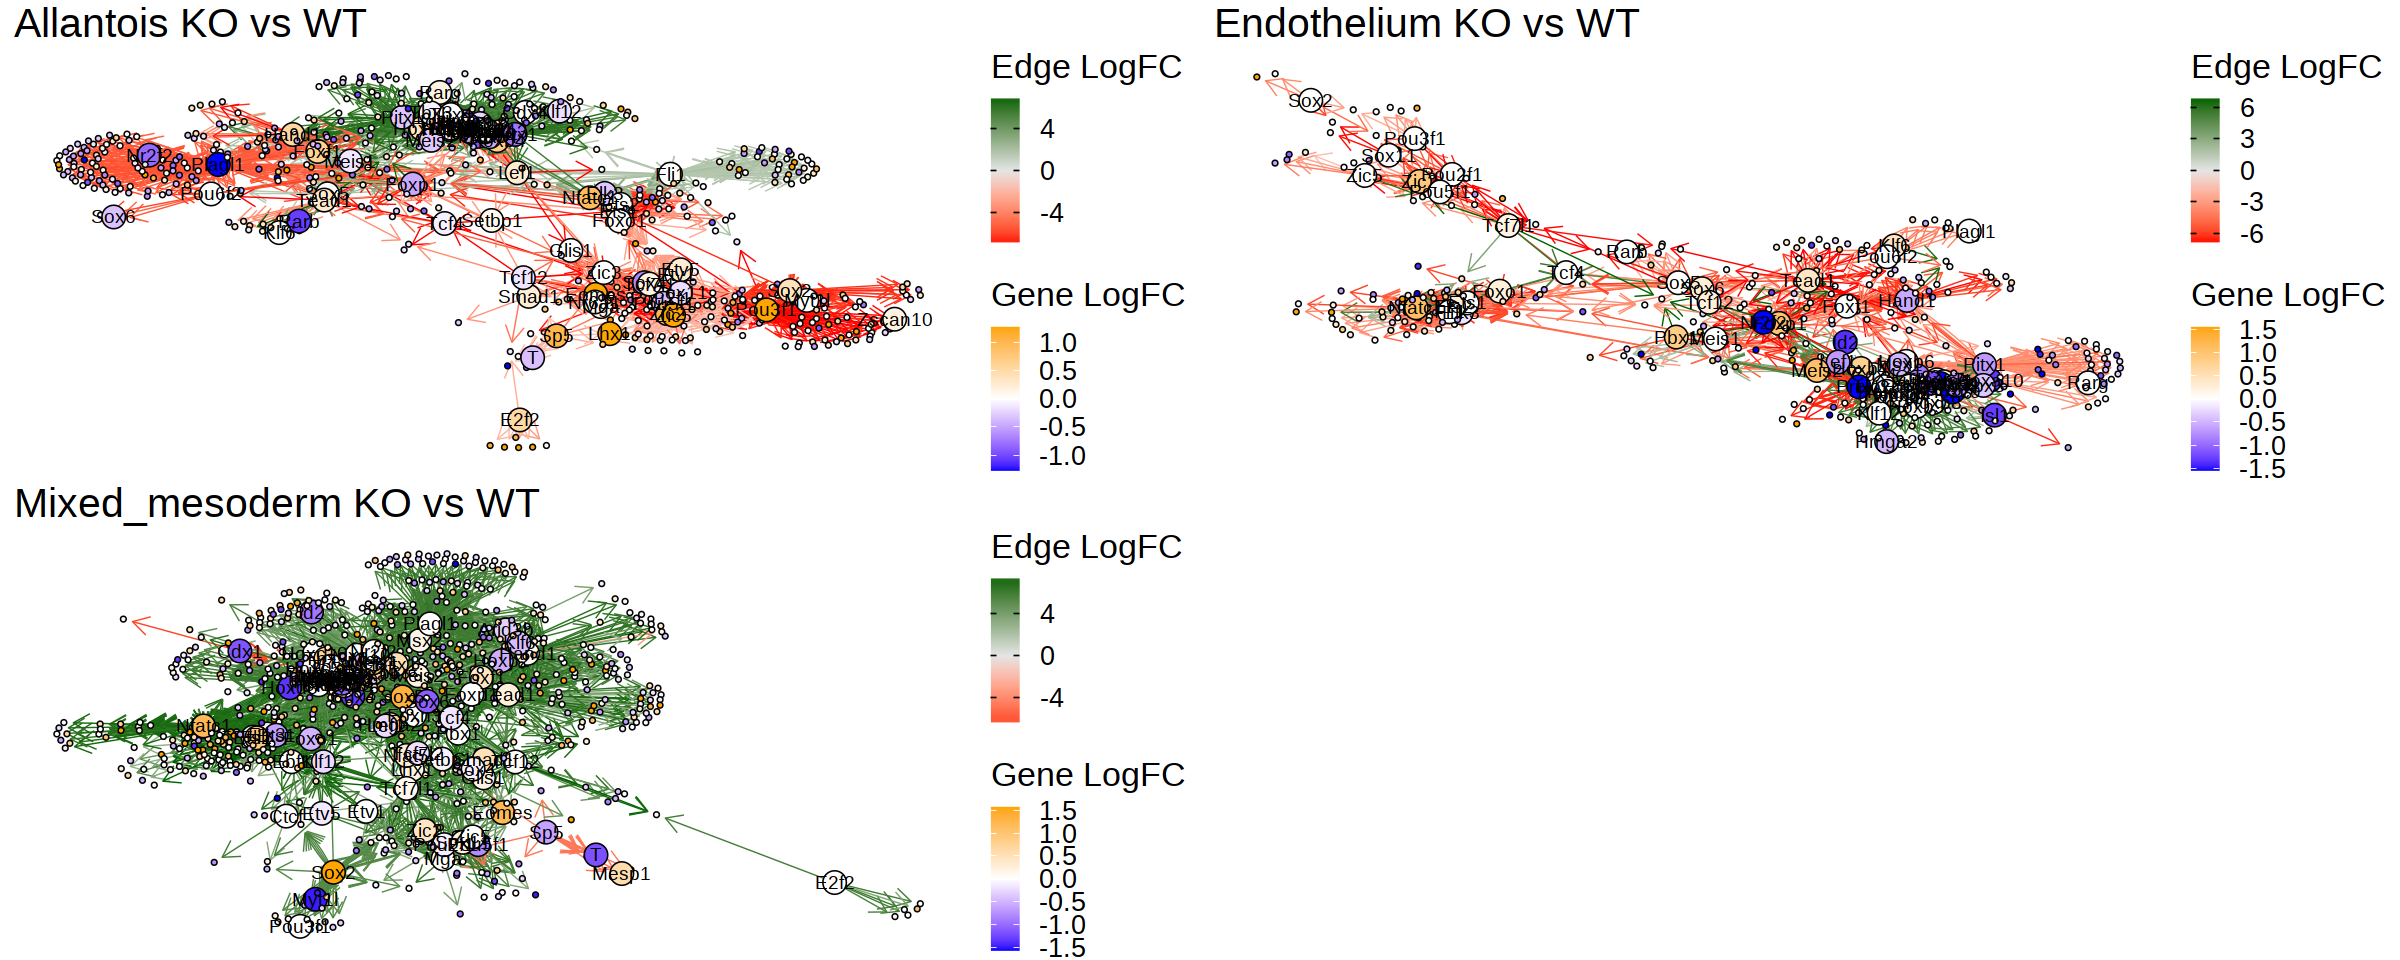

In [277]:
options(repr.plot.width=20, repr.plot.height=15)
ggarrange(
    plot_network('Allantois', 1.5),
    plot_network('Endothelium', 1.5),
    plot_network('Mixed_mesoderm', 3)
)

# Minmax normalisation

In [162]:
minmax = function(x){
    (x - min(x))/(max(x) - min(x))
}

In [163]:
# Minmax normalise RNA
pseudobulk_replicate_rna.minmax = pseudobulk_replicate_rna[rowSums(counts(pseudobulk_replicate_rna))>1]
logcounts(pseudobulk_replicate_rna.minmax) = apply(logcounts(pseudobulk_replicate_rna.minmax), 1, minmax) %>% t()
counts(pseudobulk_replicate_rna.minmax) = apply(logcounts(pseudobulk_replicate_rna.minmax), 1, minmax) %>% t()

In [164]:
# Minmax normalise RNA
pseudobulk_replicate_atac.minmax = pseudobulk_replicate_atac[rowSums(counts(pseudobulk_replicate_atac))>1]
logcounts(pseudobulk_replicate_atac.minmax) = apply(logcounts(pseudobulk_replicate_atac.minmax), 1, minmax) %>% t()
counts(pseudobulk_replicate_atac.minmax) = apply(counts(pseudobulk_replicate_atac.minmax), 1, minmax) %>% t()

In [165]:
eGRN_filt = eGRN_filt[TF %in% rownames(pseudobulk_replicate_rna) & Gene %in% rownames(pseudobulk_replicate_rna) & Region %in% rownames(pseudobulk_replicate_atac)]

### method 1

In [ ]:
# DEGs on RNA
DEGs <- pseudoBulkDGE(pseudobulk_replicate_rna,
    label=pseudobulk_replicate_rna$celltype,
    design=~genotype,
    coef="genotypewt",
    method='voom') %>% unlist() %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),]

In [ ]:
# DARs on ATAC
DARs <- pseudoBulkDGE(pseudobulk_replicate_atac,
    label=pseudobulk_replicate_atac$celltype,
    design=~genotype,
    coef="genotypewt",
    method='edgeR') %>% unlist() %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(Region=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),]

In [ ]:
plot_network = function(celltype_i, logFC_RNA, logFC_ATAC, logFC_edge){
    tmp = eGRN_filt[,c('TF', 'Region', 'Gene')] %>%
        merge(., DEGs[celltype==celltype_i, c('gene', 'logFC', 'FDR')], by.x='TF', by.y='gene') %>%
        setnames(c('logFC', 'FDR'), c('logFC_RNA', 'FDR_RNA')) %>%
        merge(., DARs[celltype==celltype_i, c('Region', 'logFC', 'FDR')], by='Region') %>%
        setnames(c('logFC', 'FDR'), c('logFC_ATAC', 'FDR_ATAC')) %>% 
        .[,`:=`(FC_RNA = 2^logFC_RNA, FC_ATAC = 2^logFC_ATAC)] %>%
        .[,edge_FC := FC_RNA * FC_ATAC] %>%
        .[,edge_logFC := log2(edge_FC)]

    edges = tmp[abs(edge_logFC) > logFC_edge] %>%
            .[, c('TF', 'Region', 'Gene', 'edge_logFC')] %>%
            .[order(-abs(edge_logFC))] %>%
            unique(by=c('TF', 'Gene')) %>% 
            .[, N:=.N, by=TF] %>% .[N>3] %>%
            .[,edge_logFC:= ifelse(edge_logFC <= -quantile(abs(edge_logFC), .95), -quantile(abs(edge_logFC), .95), 
                                   ifelse(edge_logFC>=quantile(abs(edge_logFC), .95), quantile(abs(edge_logFC), .95), edge_logFC))]# quantile cutoff logFC

    nodes = data.table(gene = unique(c(edges$TF, edges$Gene))) %>%
            .[,type:=ifelse(gene %in% all_TFs, 'TF', 'TG')] %>%
            .[,size:=ifelse(type=='TF', 4, 1.5)] %>%
            merge(.,DEGs[celltype==celltype_i,c('gene', 'logFC', 'FDR')], by='gene', all.x=TRUE) %>%
           .[gene %in% unique(c(edges$TF, edges$Gene)),] %>%
           .[,logFC:=ifelse(FDR>0.05, 0, logFC)] %>%
           .[,logFC:=ifelse(is.na(logFC), 0, logFC)] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC
    
    igraph.tbl_tmp = tbl_graph(edges = edges[, c('TF', 'Gene', 'edge_logFC')], nodes = nodes)

    options(repr.plot.width=20, repr.plot.height=8)
    p = ggraph(igraph.tbl_tmp, 'fr') + #'fr'
        # Edges
            geom_edge_fan(aes( edge_color=edge_logFC), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(2,'mm'), show.legend = T) + #filter=score>score_thr, 
            scale_edge_alpha_continuous(range=c(0,1), name='abs(edge logFC)') +
            scale_edge_colour_gradient2(low='red', mid='grey90', high='darkgreen', name='Edge LogFC') +
            # Nodes
            geom_node_point(aes(fill=logFC, size=size), shape=21) + #It looks nice to filter above a threshold but it's not fair because TF-peak are higher than peak-target, and there is no minmax norm so far
            geom_node_text(aes(filter=type=='TF', label=gene)) + # , size=3.75| type=='target'
            scale_fill_gradient2(low='blue', mid='white', high='orange', name='Gene LogFC') +
            scale_size_continuous(range(1,2), guide='none') + 
            # theme
            theme_graph() + theme(
                    legend.position = "right",
                    text=element_text(size=20)) + 
            ggtitle(paste(celltype_i, 'KO vs WT'))
    return(p)
}

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)
ggarrange(
    plot_network('Allantois', 1.5, 1, 2),
    plot_network('Endothelium', 1.5, 1, 2),
    plot_network('Mixed_mesoderm', 1.5, 1, 2)
)

### Method 2
Done first because it sounds easier to implement

In [166]:
# Create SCE where rows are GRN edges and columns are replicates
# for every replicate, multiply TF * acc -> make dataframe with values
# then cbind all
edge_values.dt = mclapply(unique(colnames(pseudobulk_replicate_atac)), function(x){
           tmp = data.table(idx = eGRN_filt$idx,
                            group_replicate = x,
                            logcounts(pseudobulk_replicate_rna.minmax[eGRN_filt$TF,x]),
                            logcounts(pseudobulk_replicate_atac.minmax[eGRN_filt$Region,x])) %>% 
                 setnames(c('idx', 'group_replicate', 'RNA', 'ATAC')) %>%
                 .[,edge_value := round(RNA * ATAC, 2)] %>%
                 .[,c('idx', 'group_replicate','RNA', 'ATAC', 'edge_value')]
            return(tmp)
}, mc.cores=16) %>% rbindlist() %>%
    .[,celltype:=str_split(group_replicate, '-') %>% map_chr(1)] %>%
    .[,int:=str_split(group_replicate, '-') %>% map_chr(2)] %>%
    .[,int:=gsub('eomes_ko', 'ko', int)] %>%
     .[,`:=`(genotype = str_split(int, '_') %>% map_chr(1),
             replicate = str_split(int, '_') %>% map_chr(2))] %>%
    .[,int:=NULL]


In [167]:
head(edge_values.dt)

idx,group_replicate,RNA,ATAC,edge_value,celltype,genotype,replicate
<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,Epiblast-wt_rep1,0.1686211,0.7526297,0.13,Epiblast,wt,rep1
2,Epiblast-wt_rep1,0.1686211,0.7526297,0.13,Epiblast,wt,rep1
3,Epiblast-wt_rep1,0.1686211,0.7526297,0.13,Epiblast,wt,rep1
4,Epiblast-wt_rep1,0.4943716,0.8703695,0.43,Epiblast,wt,rep1
5,Epiblast-wt_rep1,0.4943716,0.8703695,0.43,Epiblast,wt,rep1
6,Epiblast-wt_rep1,0.4943716,0.8703695,0.43,Epiblast,wt,rep1


In [168]:
unique(edge_values.dt$celltype)

[1] "Epiblast"                       "Primitive_Streak"              
 [3] "Anterior_Primitive_Streak"      "Nascent_mesoderm"              
 [5] "Forebrain_Midbrain_Hindbrain"   "Rostral_neurectoderm"          
 [7] "Surface_ectoderm"               "Intermediate_mesoderm"         
 [9] "Mixed_mesoderm"                 "PGC"                           
[11] "ExE_mesoderm"                   "Haematoendothelial_progenitors"
[13] "Pharyngeal_mesoderm"            "Mesenchyme"                    
[15] "Caudal_epiblast"                "Gut"                           
[17] "Somitic_mesoderm"               "Def._endoderm"                 
[19] "Allantois"                      "Blood_progenitors_1"           
[21] "Erythroid1"                     "Endothelium"                   
[23] "Blood_progenitors_2"

In [169]:
celltype_i = 'Mixed_mesoderm'

tmp = edge_values.dt[celltype==celltype_i]
head(tmp)

idx,group_replicate,RNA,ATAC,edge_value,celltype,genotype,replicate
<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,Mixed_mesoderm-wt_rep1,0.4983738,0.8498560,0.42,Mixed_mesoderm,wt,rep1
2,Mixed_mesoderm-wt_rep1,0.4983738,0.8498560,0.42,Mixed_mesoderm,wt,rep1
3,Mixed_mesoderm-wt_rep1,0.4983738,0.8498560,0.42,Mixed_mesoderm,wt,rep1
4,Mixed_mesoderm-wt_rep1,0.7377219,0.8669762,0.64,Mixed_mesoderm,wt,rep1
5,Mixed_mesoderm-wt_rep1,0.7377219,0.8669762,0.64,Mixed_mesoderm,wt,rep1
6,Mixed_mesoderm-wt_rep1,0.7377219,0.8669762,0.64,Mixed_mesoderm,wt,rep1


In [172]:
tmp2 = mclapply(unique(tmp$idx), mc.cores=1, function(x){
    tmp2 = tmp[idx==x] %>%
                .[,mean_edge_value:=mean(edge_value), by='genotype']
    
    keep_edge = unique(tmp2[mean_edge_value>0.4, idx]) # only keep edges that have a mean value of 0.25 in either WT or KO
    
    if(x %in% keep_edge){
            tmp3 = data.table(idx = x, 
                          celltype = celltype_i,
                         logFC = log2(unique(tmp2[genotype=='ko',mean_edge_value])/unique(tmp2[genotype=='wt',mean_edge_value])),
                         pvalue =  t.test(tmp2[genotype=='ko',edge_value], tmp2[genotype=='wt',edge_value], alternative ="two.sided")$p.value)
    }
}) %>% rbindlist() %>%
         .[,FDR:=p.adjust(pvalue, method ='BH', nrow(.))] %>%
         .[order(FDR)] %>%
         .[,sig:=ifelse(FDR<0.05 & abs(logFC)>0.25, TRUE, FALSE)]

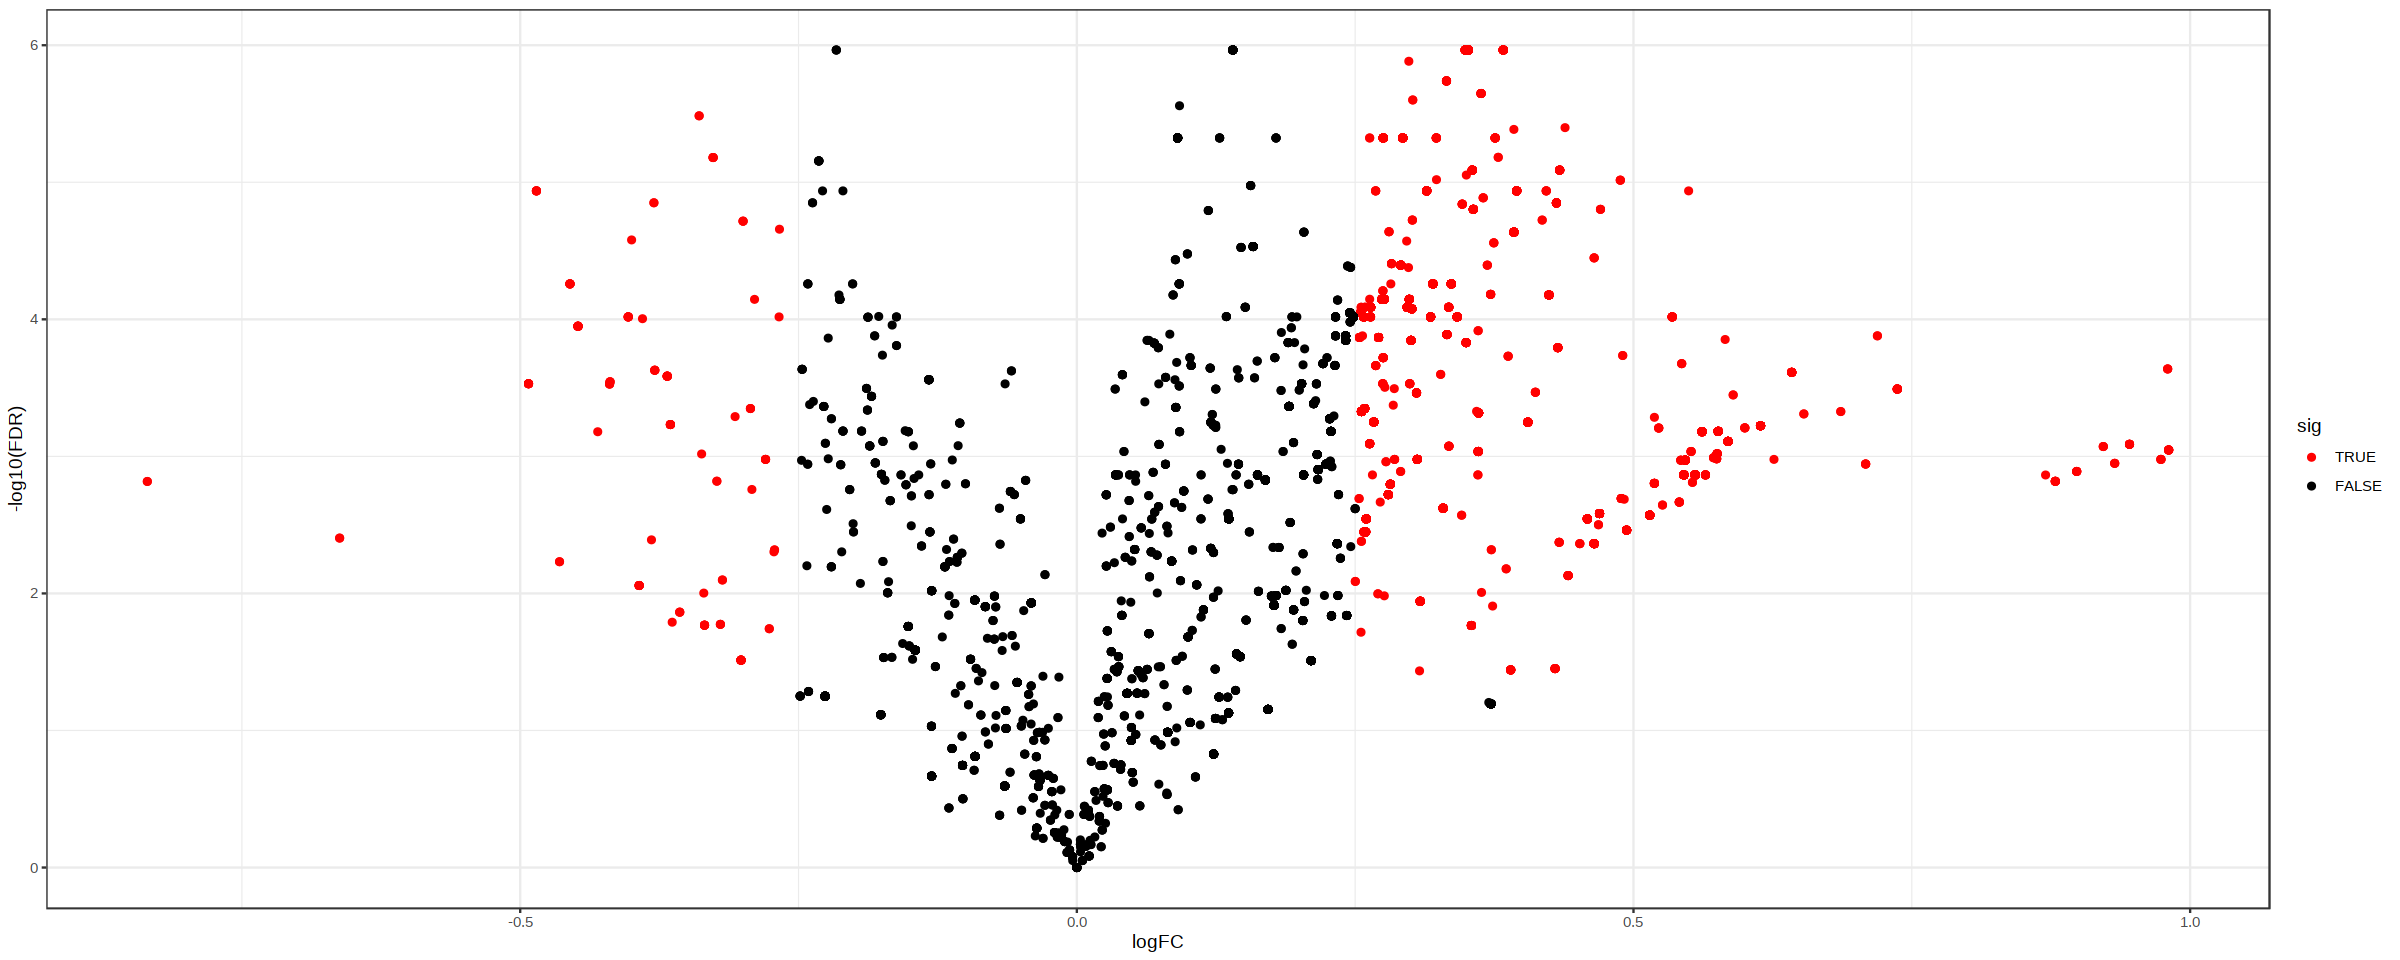

In [173]:
ggplot(tmp2, aes(logFC, -log10(FDR), col=sig)) + 
    geom_point() + 
    scale_color_manual(values=c('TRUE'= 'red', 'FALSE'= 'black')) + 
    theme_bw()

In [174]:
tmp3 = merge(tmp2, eGRN_filt[,c('idx', 'TF', 'Region', 'Gene')], by='idx')

In [175]:
head(tmp3[sig==TRUE][order(-abs(logFC))])

idx,celltype,logFC,pvalue,FDR,sig,TF,Region,Gene
<int>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>
8174,Mixed_mesoderm,0.9807209,0.000397325,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8175,Mixed_mesoderm,0.9807209,0.000397325,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8176,Mixed_mesoderm,0.9807209,0.000397325,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8177,Mixed_mesoderm,0.9807209,0.000397325,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8178,Mixed_mesoderm,0.9807209,0.000397325,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8179,Mixed_mesoderm,0.9807209,0.000397325,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2


In [200]:
head(tmp3[sig==TRUE][order(-abs(logFC))], 100)

idx,celltype,logFC,pvalue,FDR,sig,TF,Region,Gene
<int>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>
8174,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8175,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8176,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8177,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8178,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8179,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8180,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
8181,Mixed_mesoderm,0.9807209,3.973250e-04,0.0008981228,TRUE,Hoxd4,chr5:147309081-147309681,Cdx2
3725,Mixed_mesoderm,0.9798221,6.989062e-05,0.0002301942,TRUE,Hoxa5,chr6:119583942-119584542,Wnt5b


In [176]:
table(tmp3[sig==TRUE & logFC>0, TF])
table(tmp3[sig==TRUE & logFC<0, TF])


Arid3b   Cdx2   Cdx4  Hoxa3  Hoxa5  Hoxb3  Hoxb8  Hoxb9  Hoxd3  Hoxd4  Hoxd8 
    14   1059    727      5      3      1     19    945     21     38      8 
 Hoxd9 Pou5f1    Sp5   Tcf4 
   373      4      4      6 


Foxp4 Hoxd1 Meis1 Mesp2  Msx2  Pbx3 Sox11  Sox2  Sox5 Tead1 
    1    16    23     2     3     1    19     2     8    59 

In [177]:
table(tmp3[FDR<.05 & logFC>1, TF])
table(tmp3[FDR<.05 & logFC<=-1, TF])

< table of extent 0 >

< table of extent 0 >

In [178]:
#calc_edge_stats = function(celltype_i = 'Mixed_mesoderm', min_edgeW=0.4, TF_expr_thr=4){
celltype_i = 'Mixed_mesoderm'
min_edgeW=0.4
TF_expr_thr=4

    # Extract celltype-genotype GRN
    GRN_pseudobulk_ko = GRN_pseudobulk[celltype==celltype_i & genotype=='eomes_ko'] %>% 
        .[,mean_edge_weight:=mean(edge_weight), by=c('TF', 'Region', 'Gene', 'sample')]
    GRN_pseudobulk_wt = GRN_pseudobulk[celltype==celltype_i & genotype=='wt'] %>% 
        .[,mean_edge_weight:=mean(edge_weight), by=c('TF', 'Region', 'Gene', 'sample')]

    # Keep only TFs that are highly expressed
    mean_TF_expr_ko = GRN_pseudobulk_ko[,c('TF', 'Expr')] %>% 
        .[, mean_expr:=mean(Expr), by='TF'] %>% 
        .[mean_expr>TF_expr_thr, TF] %>% unique(by='TF')
    
    mean_TF_expr_wt = GRN_pseudobulk_wt[,c('TF', 'Expr')] %>% 
        .[, mean_expr:=mean(Expr), by='TF'] %>% 
        .[mean_expr>TF_expr_thr, TF] %>% unique(by='TF')
    
    keep_TFs = unique(c(mean_TF_expr_ko, mean_TF_expr_wt))
    GRN_pseudobulk_ko = GRN_pseudobulk_ko[TF %in% keep_TFs]
    GRN_pseudobulk_wt = GRN_pseudobulk_wt[TF %in% keep_TFs]

    
    if(nrow(GRN_pseudobulk_ko) != 0 & nrow(GRN_pseudobulk_wt) != 0){
    
    # keep only edges above certain weight in either KO or WT
    edges_keep = rbind(GRN_pseudobulk_ko[mean_edge_weight>=min_edgeW, c('TF', 'Region', 'Gene')],
                          GRN_pseudobulk_wt[mean_edge_weight>=min_edgeW, c('TF', 'Region', 'Gene')]) %>%
                    unique(by=c('TF', 'Region', 'Gene')) %>% 
                    .[,idx:=.I]

    GRN_pseudobulk_ko = merge(edges_keep, GRN_pseudobulk_ko, by=c('TF', 'Region', 'Gene'))
    GRN_pseudobulk_wt = merge(edges_keep, GRN_pseudobulk_wt, by=c('TF', 'Region', 'Gene'))
    
    #lapply(unique(edges_keep$idx), function(x){
    edge_stats = lapply(unique(edges_keep$idx), function(x){
    ko_tmp = GRN_pseudobulk_ko[idx==x, edge_weight]
    wt_tmp = GRN_pseudobulk_wt[idx==x, edge_weight]

    tmp = data.table(TF = GRN_pseudobulk_ko[idx==x, TF][1], 
                     Region = GRN_pseudobulk_ko[idx==x, Region][1], 
                     Gene = GRN_pseudobulk_ko[idx==x, Gene][1], 
                     logFC = log2(abs(mean(ko_tmp)) / abs(mean(wt_tmp))),
                     TF_logFC = log2(abs(mean(GRN_pseudobulk_ko[idx==x, Expr_minmax])) / abs(mean(GRN_pseudobulk_wt[idx==x, Expr_minmax]))),
                     Gene_logFC = log2(abs(mean(GRN_pseudobulk_ko[idx==x, Gene_Expr_minmax])) / abs(mean(GRN_pseudobulk_wt[idx==x, Gene_Expr_minmax]))),
                     pvalue =  t.test(ko_tmp, wt_tmp, alternative ="two.sided")$p.value)
    }) %>% rbindlist() %>%
         .[,FDR:=p.adjust(pvalue, method ='BH', nrow(.))] %>%
         .[order(FDR)] %>%
         .[,sig:=ifelse(FDR<0.05 & abs(logFC)>2, TRUE, FALSE)] %>%
         .[,logFC_capped:=ifelse(logFC<=-4, -4, ifelse(logFC>=4, 4, logFC))]

        edge_stats = edge_stats[,sig:=ifelse(FDR<0.05 & abs(logFC)>0.5, TRUE, FALSE)]
        return(edge_stats)
    }
#}

ERROR: Error in GRN_pseudobulk[celltype == celltype_i & genotype == "eomes_ko"] %>% : object 'GRN_pseudobulk' not found


In [546]:
# Convert to matrix
edge_values.mtx = dcast(edge_values.dt, idx ~ group_replicate, value.var = "edge_value") %>% 
    as.data.frame() %>%
    tibble::column_to_rownames('idx') %>%
    as.matrix()

# Convert to SCE
edge_values.sce = SingleCellExperiment(list(counts = edge_values.mtx))
colData(edge_values.sce) = colData(pseudobulk_replicate_rna)

In [547]:
edge_values.sce

class: SingleCellExperiment 
dim: 30853 185 
metadata(0):
assays(1): counts
rownames(30853): 1 2 ... 35529 35530
rowData names(0):
colnames(185): Epiblast-wt_rep1 Epiblast-wt_rep2 ...
  Endothelium-eomes_ko_rep4 Endothelium-eomes_ko_rep5
colData names(16): barcode sample ... ncells celltype
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [552]:
counts(edge_values.sce) = apply(counts(edge_values.sce), 1, minmax) %>% t()

In [554]:
# Differential test with limma using pseudoBulkDGE

between.res <- pseudoBulkDGE(edge_values.sce,
    label=edge_values.sce$celltype,
    design=~0 + genotype,
    coef="genotypewt",
    method='voom') %>% unlist() %>% 
            setnames('gene', 'idx') %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & adj.P.Val<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),]

ERROR: Error in voom(counts, design = design, lib.size = lib.size, normalize.method = normalize.method, : Need at least two genes to fit a mean-variance trend


In [ ]:
plot_network = function(celltype_i, logFC_i){
    edges = between.res[celltype==celltype_i & sig==TRUE & abs(logFC) > logFC_i] %>%
                .[, idx:=as.integer(idx)] %>%
                merge(., eGRN_filt, by= 'idx') %>%
                .[, c('TF', 'Region', 'Gene', 'logFC')] %>%
                .[, N:=.N, by=TF] %>% .[N>3] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC

    nodes = data.table(gene = unique(c(edges$TF, edges$Gene))) %>%
            .[,type:=ifelse(gene %in% all_TFs, 'TF', 'TG')] %>%
            .[,size:=ifelse(type=='TF', 4, 1.5)]
    
    igraph.tbl_tmp = tbl_graph(edges = edges[, c('TF', 'Gene', 'logFC')], nodes = nodes)

    #options(repr.plot.width=20, repr.plot.height=8)
    p = ggraph(igraph.tbl_tmp, 'fr') + #'fr'
        # Edges
            geom_edge_fan(aes( edge_color=logFC), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(2,'mm'), show.legend = T) + #filter=score>score_thr, 
            scale_edge_alpha_continuous(range=c(0,1), name='abs(edge logFC)') +
            scale_edge_colour_gradient2(low='red', mid='grey90', high='darkgreen', name='Edge LogFC') +
            # Nodes
            geom_node_point(aes(size=size), shape=21) + #It looks nice to filter above a threshold but it's not fair because TF-peak are higher than peak-target, and there is no minmax norm so far
            geom_node_text(aes(filter=type=='TF', label=gene)) + # , size=3.75| type=='target'
         #   scale_fill_gradient2(low='blue', mid='white', high='orange', name='Gene LogFC') +
            scale_size_continuous(range(1,2), guide='none') + 
            # theme
            theme_graph() + theme(
                    legend.position = "right",
                    text=element_text(size=20)) + 
            ggtitle(paste(celltype_i, 'KO vs WT'))
    return(p)
}

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)
ggarrange(
    plot_network('Allantois', 1.5),
    plot_network('Endothelium', 1.5),
    plot_network('Mixed_mesoderm', 3)
)

# Pseudbulk mean instead of sum

#### RNA Pseudobulking with artificial replicates

In [179]:
sce = readRDS(args$rna.counts)[, sample_metadata$cell]

In [180]:
sce = sce[unique(c(eGRN_filt$TF, eGRN_filt$Gene)),]

In [181]:
# replicates will be made per pool, celltype, and tdTom_corr status
#sample_metadata$group = paste0(sample_metadata$celltype.mapped_mnn, '_', sample_metadata$tdTom_corr)
sample_metadata$group = sample_metadata$celltype_genotype
sce$group = sample_metadata$group 

pseudobulk_replicate = mclapply(unique(replicates$group), function(i){
    summed_list = list()
    tmp = replicates[group==i]
    if(nrow(tmp) >= 25){
        message(i)
        for(x in 1:5){
            # sample 80% of cells per pseudoreplicate
            cells = tmp[replicate == x, cell]
            sce_tmp = sce[,cells]
            sce_tmp$ncells = length(cells)

            summed_list[[x]] <- aggregateAcrossCells(sce_tmp, id=sce_tmp$group, statistics='mean',  BPPARAM = BPPARAM)
            colnames(summed_list[[x]]) = paste0(colnames(summed_list[[x]]), '_rep', x)
            }
        pseudobulk_group = do.call('cbind', summed_list)
        return(pseudobulk_group)
    }
}, mc.cores=16) 
pseudobulk_replicate = do.call('cbind', compact(pseudobulk_replicate))

In [182]:
pseudobulk_replicate_rna = pseudobulk_replicate

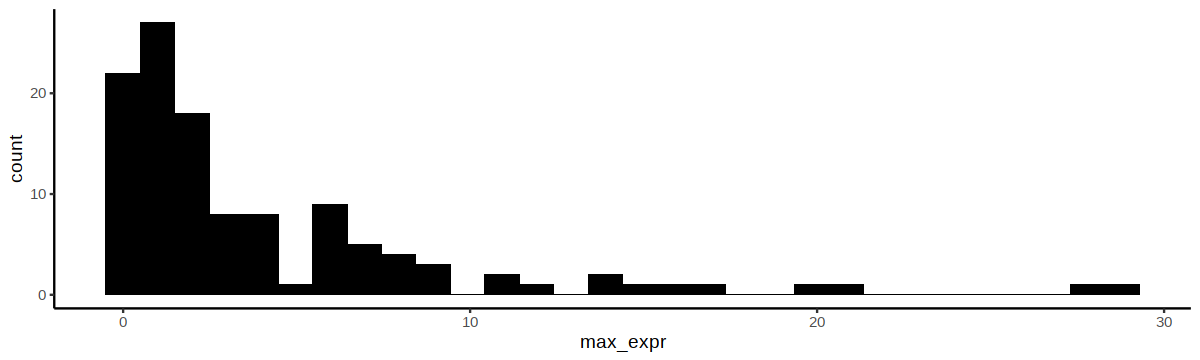

In [183]:
# filter selected TFs 
all_TFs = all_TFs[all_TFs %in% rownames(pseudobulk_replicate)]
max_expr = data.table(TF = all_TFs, max_expr = rowMax(counts(pseudobulk_replicate[all_TFs,])))
options(repr.plot.width=10, repr.plot.height=3)
ggplot(max_expr, aes(max_expr)) + geom_histogram(fill='black',bins = 30) + theme_classic()

# Keep only TFs that have a minimum of expression of 4 in one replicate
TF_keep = max_expr[max_expr>4, TF]

In [184]:
pseudobulk_replicate_rna$celltype = str_split(pseudobulk_replicate_rna$group, '-') %>% map_chr(1)

#### ATAC Pseudobulking with artificial replicates

In [185]:
sce = readRDS(args$atac.counts)[, sample_metadata$cell]

In [186]:
sce = sce[unique(eGRN_filt$Region),]

In [187]:
sce@assays@data$counts = sce@assays@data$PeakMatrix_atlas

In [188]:
# replicates will be made per pool, celltype, and tdTom_corr status
#sample_metadata$group = paste0(sample_metadata$celltype.mapped_mnn, '_', sample_metadata$tdTom_corr)
sample_metadata$group = sample_metadata$celltype_genotype
sce$group = sample_metadata$group 

pseudobulk_replicate = mclapply(unique(replicates$group), function(i){
    summed_list = list()
    tmp = replicates[group==i]
    if(nrow(tmp) >= 25){
        message(i)
        for(x in 1:5){
            # sample 80% of cells per pseudoreplicate
            cells = tmp[replicate == x, cell]
            sce_tmp = sce[,cells]
            sce_tmp$ncells = length(cells)

            summed_list[[x]] <- aggregateAcrossCells(sce_tmp, id=sce_tmp$group, statistics='mean', BPPARAM = BPPARAM)
            colnames(summed_list[[x]]) = paste0(colnames(summed_list[[x]]), '_rep', x)
            }
        pseudobulk_group = do.call('cbind', summed_list)
        return(pseudobulk_group)
    }
}, mc.cores=16) 
pseudobulk_replicate = do.call('cbind', compact(pseudobulk_replicate))

In [189]:
pseudobulk_replicate = as(pseudobulk_replicate, 'SingleCellExperiment')

In [190]:
pseudobulk_replicate_atac = pseudobulk_replicate

In [191]:
pseudobulk_replicate_atac$celltype = str_split(pseudobulk_replicate_atac$group, '-') %>% map_chr(1)

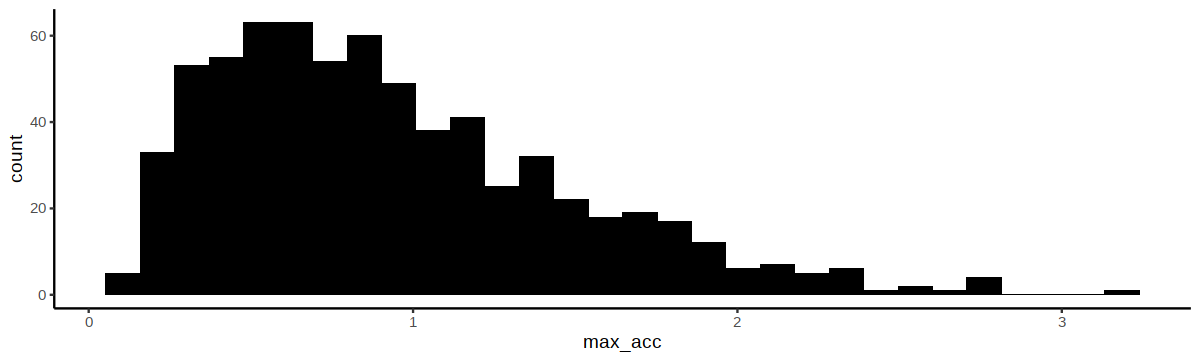

In [192]:
max_acc = data.table(region = rownames(pseudobulk_replicate_atac), max_acc = rowMax(c(pseudobulk_replicate_atac)))
options(repr.plot.width=10, repr.plot.height=3)
ggplot(max_acc, aes(max_acc)) + geom_histogram(fill='black',bins = 30) + theme_classic()

# Keep only regions that have a minimum of expression 
# Nice normal distribution so I'm only going to exclude very bottom part
regions_keep = max_acc[max_acc>1, region]

#### Filter eGRN based on maximum expression & accessibility

In [193]:
eGRN_filt = eGRN_filt[TF %in% TF_keep & Region %in% regions_keep] %>%
    .[,idx:=.I]

In [194]:
# subset ATAC 
pseudobulk_replicate_atac = pseudobulk_replicate_atac[unique(eGRN_filt$Region),]

In [195]:
# subset RNA
pseudobulk_replicate_rna = pseudobulk_replicate_rna[unique(c(eGRN_filt$TF, eGRN_filt$Gene))]

### Method 2
doesn't really seem to work well eventhough most similar to previous approach

In [196]:
# Create SCE where rows are GRN edges and columns are replicates
# for every replicate, multiply TF * acc -> make dataframe with values
# then cbind all
edge_values.dt = mclapply(unique(colnames(pseudobulk_replicate_atac)), function(x){
           tmp = data.table(idx = eGRN_filt$idx,
                            group_replicate = x,
                            counts(pseudobulk_replicate_rna[eGRN_filt$TF,x]),
                            counts(pseudobulk_replicate_atac[eGRN_filt$Region,x])) %>% 
                 setnames(c('idx', 'group_replicate', 'RNA', 'ATAC')) %>%
                 .[,edge_value := round(RNA * ATAC, 2)] %>%
                 .[,c('idx', 'group_replicate', 'edge_value')]
            return(tmp)
}, mc.cores=16) %>% rbindlist()


In [197]:
# Convert to matrix
edge_values.mtx = dcast(edge_values.dt, idx ~ group_replicate, value.var = "edge_value") %>% 
    as.data.frame() %>%
    tibble::column_to_rownames('idx') %>%
    as.matrix()

# Convert to SCE
edge_values.sce = SingleCellExperiment(list(counts = edge_values.mtx))
colData(edge_values.sce) = colData(pseudobulk_replicate_rna)

In [198]:
# Differential test with limma using pseudoBulkDGE

between.res <- pseudoBulkDGE(edge_values.sce,
    label=edge_values.sce$celltype,
    design=~genotype,
    coef="genotypewt",
    method='voom') %>% unlist() %>% 
            as.data.table(keep.rownames=T) %>%
            .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                    celltype=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                    rn=NULL, 
                    stage=paste(args$stage, collapse='_'), # add stage
                    sig=ifelse(abs(logFC)>=1 & adj.P.Val<=0.05, TRUE, FALSE))] %>%  # significance
            .[!is.na(logFC),] %>%
            setnames('gene', 'idx')

ERROR: Error in voom(counts, design = design, lib.size = lib.size, normalize.method = normalize.method, : Need at least two genes to fit a mean-variance trend


In [ ]:
plot_network = function(celltype_i, logFC_i){
    edges = between.res[celltype==celltype_i & sig==TRUE & abs(logFC) > logFC_i] %>%
                .[, idx:=as.integer(idx)] %>%
                merge(., eGRN_filt, by= 'idx') %>%
                .[, c('TF', 'Region', 'Gene', 'logFC')] %>%
                .[, N:=.N, by=TF] %>% .[N>3] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC

    nodes = data.table(gene = unique(c(edges$TF, edges$Gene))) %>%
            .[,type:=ifelse(gene %in% all_TFs, 'TF', 'TG')] %>%
            .[,size:=ifelse(type=='TF', 4, 1.5)] %>%
            merge(.,DEGs[celltype==celltype_i,c('gene', 'logFC', 'FDR')], by='gene', all.x=TRUE) %>%
           .[gene %in% unique(c(edges$TF, edges$Gene)),] %>%
            unique(by='gene') %>%
           .[,logFC:=ifelse(FDR>0.05, 0, logFC)] %>%
           .[,logFC:=ifelse(is.na(logFC), 0, logFC)] %>%
                .[,logFC:= ifelse(logFC <= -quantile(abs(logFC), .95), -quantile(abs(logFC), .95), 
                                       ifelse(logFC>=quantile(abs(logFC), .95), quantile(abs(logFC), .95), logFC))]# quantile cutoff logFC
    
    igraph.tbl_tmp = tbl_graph(edges = edges[, c('TF', 'Gene', 'logFC')], nodes = nodes)

    options(repr.plot.width=20, repr.plot.height=8)
    p = ggraph(igraph.tbl_tmp, 'fr') + #'fr'
        # Edges
            geom_edge_fan(aes( edge_color=logFC), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(2,'mm'), show.legend = T) + #filter=score>score_thr, 
            scale_edge_alpha_continuous(range=c(0,1), name='abs(edge logFC)') +
            scale_edge_colour_gradient2(low='red', mid='grey90', high='darkgreen', name='Edge LogFC') +
            # Nodes
            geom_node_point(aes(fill=logFC, size=size), shape=21) + #It looks nice to filter above a threshold but it's not fair because TF-peak are higher than peak-target, and there is no minmax norm so far
            geom_node_text(aes(filter=type=='TF', label=gene)) + # , size=3.75| type=='target'
            scale_fill_gradient2(low='blue', mid='white', high='orange', name='Gene LogFC') +
            scale_size_continuous(range(1,2), guide='none') + 
            # theme
            theme_graph() + theme(
                    legend.position = "right",
                    text=element_text(size=20)) + 
            ggtitle(paste(celltype_i, 'KO vs WT'))
    return(p)
}

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)
ggarrange(
    plot_network('Allantois', 1.5),
    plot_network('Endothelium', 1.5),
    plot_network('Mixed_mesoderm', 3)
)